# RF Testing

In [16]:
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [17]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
qd.start_client("128.95.31.213")

## Load Default Configuration

In [21]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True
default_config.high_threshold = 2000
default_config.low_threshold = 500


default_config.mw_channel = 0
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0

default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom


# CPMG Super Resolution

In [22]:
from qickdawg.testfunctions.rftest_cpmg_xy_subnano_res import RFTest_CPMG
import copy

soc = qd.soc

config = copy.copy(default_config)

# MW params
config.mw_channel = 0
config.mw_fMHz = 1405 # 200
config.mw_gain = 32000
config.mw_nqz = 1

# Timing params
config.pi_len_samples = 160
config.tau_len_samples = 1600

# Sweep params
config.n_cpmg = 4
config.reps = 1

# random
config.readout_integration_tns = 20

# Triggering
config.trigger_width_tns = 50
config.trigger_gate_pmod = 0

prog = RFTest_CPMG(config)
prog.run_rounds(
   soc,
   rounds=1, # Adjust to N cycles?
   progress=False, #True
)

In [12]:
import pyvisa, numpy as np
rm = pyvisa.ResourceManager()
scope = rm.open_resource("TCPIP0::128.95.31.175::inst0::INSTR")

# set data format
scope.write(":DATa:ENCdg ASCii")        # or RIBinary for faster transfer
scope.write(":DATa:WIDth 1")
scope.write(":DATa:STARt 1")
scope.write(":DATa:STOP 20000")         # 20 kpts

# select channel
scope.write(":DATa:SOUrce CH1")

# query scaling information
ymult = float(scope.query(":WFMOutpre:YMUlt?"))
yzero = float(scope.query(":WFMOutpre:YZEro?"))
yoff  = float(scope.query(":WFMOutpre:YOFf?"))
xincr = float(scope.query(":WFMOutpre:XINcr?"))
xzero = float(scope.query(":WFMOutpre:XZEro?"))

# read waveform
data_str = scope.query(":CURVe?")
data = np.array([float(v) for v in data_str.split(",")])
volt = (data - yoff) * ymult + yzero
time = np.arange(len(volt)) * xincr + xzero

# save to CSV
np.savetxt(f"subnano_cpmg-{config.mw_gain}gain-{config.mw_fMHz}MHz-phase90.csv", np.column_stack([time, volt]),
           delimiter=",", header="Time(s),Voltage(V)")


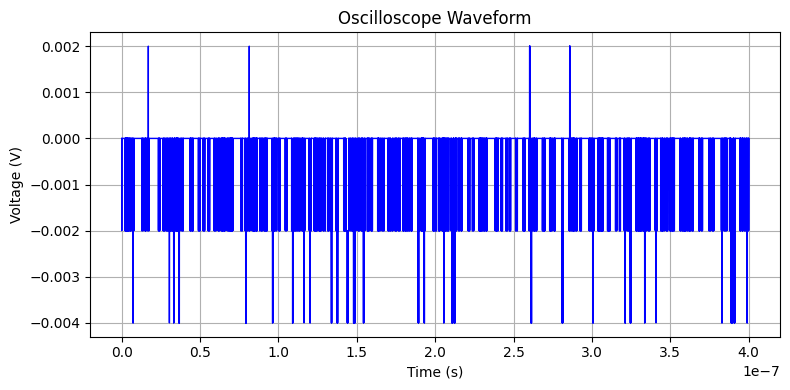

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV
# Assumes CSV has two columns: Time(s), Voltage(V) with header
data = np.loadtxt(f"subnano_cpmg-{config.mw_gain}gain-{config.mw_fMHz}MHz-phase90.csv", delimiter=",", skiprows=1)

# Separate columns
time = data[:, 0]      # first column = time
voltage = data[:, 1]   # second column = voltage

# Plot
plt.figure(figsize=(8,4))
plt.plot(time, voltage, color='blue', linewidth=1)
plt.title("Oscilloscope Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
config.tau_treg = 2000/16
config.tau_tns = 70
config.tau_treg
config.tau_tns

71.61458333333334

In [7]:
from qickdawg.testfunctions.rftest_superres_waveforms import RFTest_CPMG
import copy

soc = qd.soc

config = copy.copy(default_config)

default_config.mw_nqz = 1

# MW params
config.mw_channel = 0
config.mw_fMHz = 0.0002
config.mw_gain = 32000
config.mw_nqz = 1

# Timing params
config.pi_len_samples = 50
config.tau_len_samples = 5

# Sweep params
config.n_cpmg = 8
config.reps = 1

# random
config.readout_integration_tns = 20

# Triggering
config.trigger_width_tns = 50
config.trigger_gate_pmod = 0

prog = RFTest_CPMG(config)
prog.run_rounds(
   soc,
   rounds=1, # Adjust to N cycles?
   progress=False, #True
)


In [69]:
from qickdawg.testfunctions.rftest_waveform_amplitude import RFTest_Amplitude
import copy

soc = qd.soc

config = copy.copy(default_config)

# MW params
config.mw_channel = 0
config.mw_fMHz = 1405 # 200
config.mw_gain = 8000
config.mw_nqz = 1

# Timing params
config.waveform_len_samples = 160 * 4
config.tau_treg = 5

# Sweep params
config.reps = 1

# random
config.readout_integration_tns = 20

# Triggering
config.trigger_width_tns = 50
config.trigger_gate_pmod = 0


prog = RFTest_Amplitude(config)
prog.run_rounds(
   soc,
   rounds=1, # Adjust to N cycles?
   progress=False, #True
)

In [70]:
import pyvisa, numpy as np
rm = pyvisa.ResourceManager()
scope = rm.open_resource("TCPIP0::128.95.31.175::inst0::INSTR")

# set data format
scope.write(":DATa:ENCdg ASCii")        # or RIBinary for faster transfer
scope.write(":DATa:WIDth 1")
scope.write(":DATa:STARt 1")
scope.write(":DATa:STOP 20000")         # 20 kpts

# select channel
scope.write(":DATa:SOUrce CH1")

# query scaling information
ymult = float(scope.query(":WFMOutpre:YMUlt?"))
yzero = float(scope.query(":WFMOutpre:YZEro?"))
yoff  = float(scope.query(":WFMOutpre:YOFf?"))
xincr = float(scope.query(":WFMOutpre:XINcr?"))
xzero = float(scope.query(":WFMOutpre:XZEro?"))

# read waveform
data_str = scope.query(":CURVe?")
data = np.array([float(v) for v in data_str.split(",")])
volt = (data - yoff) * ymult + yzero
time = np.arange(len(volt)) * xincr + xzero

# save to CSV
np.savetxt(f"Waveform-Amplitude-{config.mw_gain}.csv", np.column_stack([time, volt]),
           delimiter=",", header="Time(s),Voltage(V)")


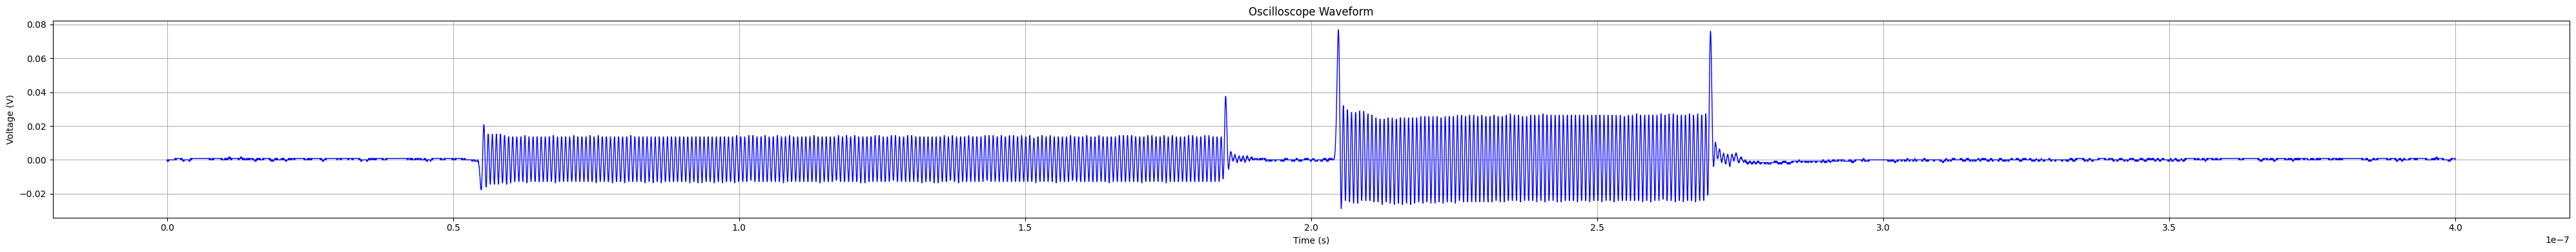

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV
# Assumes CSV has two columns: Time(s), Voltage(V) with header
data = np.loadtxt(f"Waveform-Amplitude-{config.mw_gain}.csv", delimiter=",", skiprows=1)

# Separate columns
time = data[:, 0]      # first column = time
voltage = data[:, 1]   # second column = voltage

# Plot
plt.figure(figsize=(40,4))
plt.plot(time, voltage, color='blue', linewidth=1)
plt.title("Oscilloscope Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.tight_layout()
plt.show()
